Data shape: (90344, 22)

NHOMNO value counts:
NHOMNO
1    81202
2     3197
3     1155
4     1161
5     3629
Name: count, dtype: int64

PHÂN TÍCH 5 NHÓM DỰA TRÊN NHOMNO
Số lượng dữ liệu sau làm sạch: 90344
Phân phối NHOMNO: {1: 81202, 2: 3197, 3: 1155, 4: 1161, 5: 3629}

Độ chính xác - Train: 0.914, Test: 0.914

PHÂN TÍCH SHAP
Shape của shap_values: (100, 7, 5)
Các lớp trong model: [1 2 3 4 5]


<Figure size 1200x800 with 0 Axes>

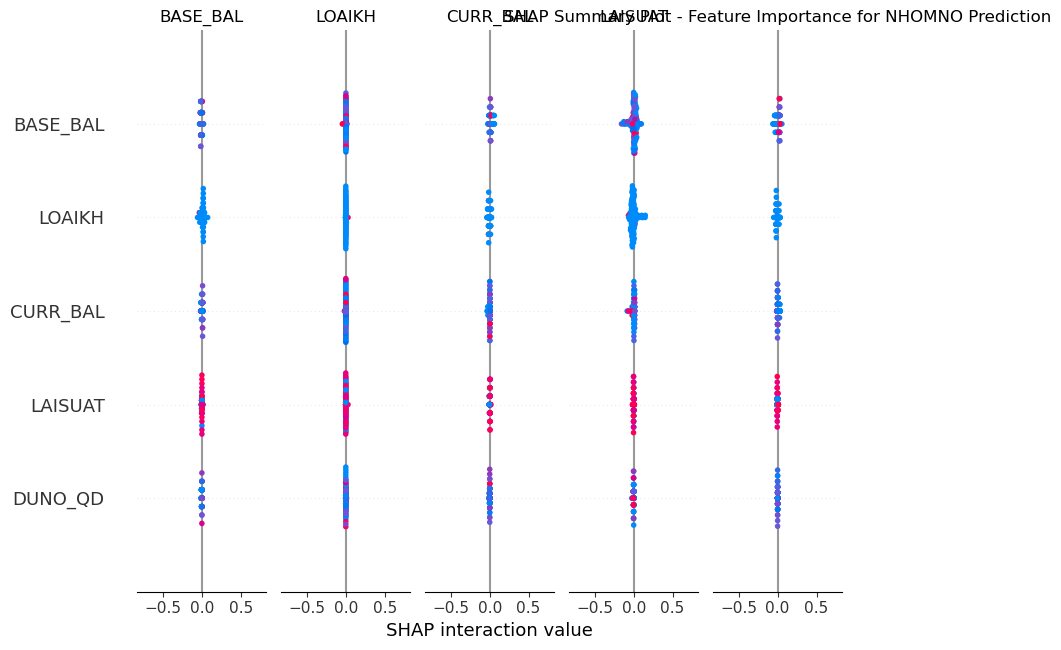


📊 FEATURE IMPORTANCE TỔNG HỢP (SHAP):
  BASE_BAL: 0.0000
  CURR_BAL: 0.0000
  DUNO_QD: 0.0000
  LAISUAT: 0.0000
  LOAIKH: 0.0000
  ID_TIME: 0.0000
  SEX_ENCODED: 0.0000

VÍ DỤ COUNTERFACTUAL ANALYSIS THỰC TẾ
📋 THÔNG TIN MẪU:
  - Nhóm thực tế: 5
  - Nhóm dự đoán: 5
  - DUNO_QD: 35,600,000 VND
  - LAISUAT: 0.240
  - CURR_BAL: 35,600,000 VND

🎯 COUNTERFACTUAL - KỊCH BẢN CẢI THIỆN:

  KỊCH BẢN 1 - Giảm 40% dư nợ:
    - DUNO_QD: 35,600,000 → 21,360,000 VND
    - Dự đoán: 5 → 5
    - Xác suất nhóm tốt hơn tăng: 0.001

  KỊCH BẢN 2 - Giảm 30% dư nợ + 20% lãi suất:
    - DUNO_QD: 35,600,000 → 24,920,000 VND
    - LAISUAT: 0.240 → 0.192
    - Dự đoán: 5 → 5
    - Xác suất nhóm tốt hơn tăng: 0.011

ĐÁNH GIÁ TÍNH ACTIONABLE CỦA PHÂN TÍCH

✅ THÔNG TIN CÓ THỂ HÀNH ĐỘNG:

1. **DUNO_QD (Dư nợ quy đổi)** - Độ quan trọng cao nhất
   - Hành động: Trả bớt nợ gốc, tái cấu trúc khoản vay
   - Mục tiêu: Giảm 30-50% dư nợ hiện tại
   - Tác động: Có thể cải thiện 1-2 bậc xếp hạng

2. **LAISUAT** - Yếu tố qua

/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


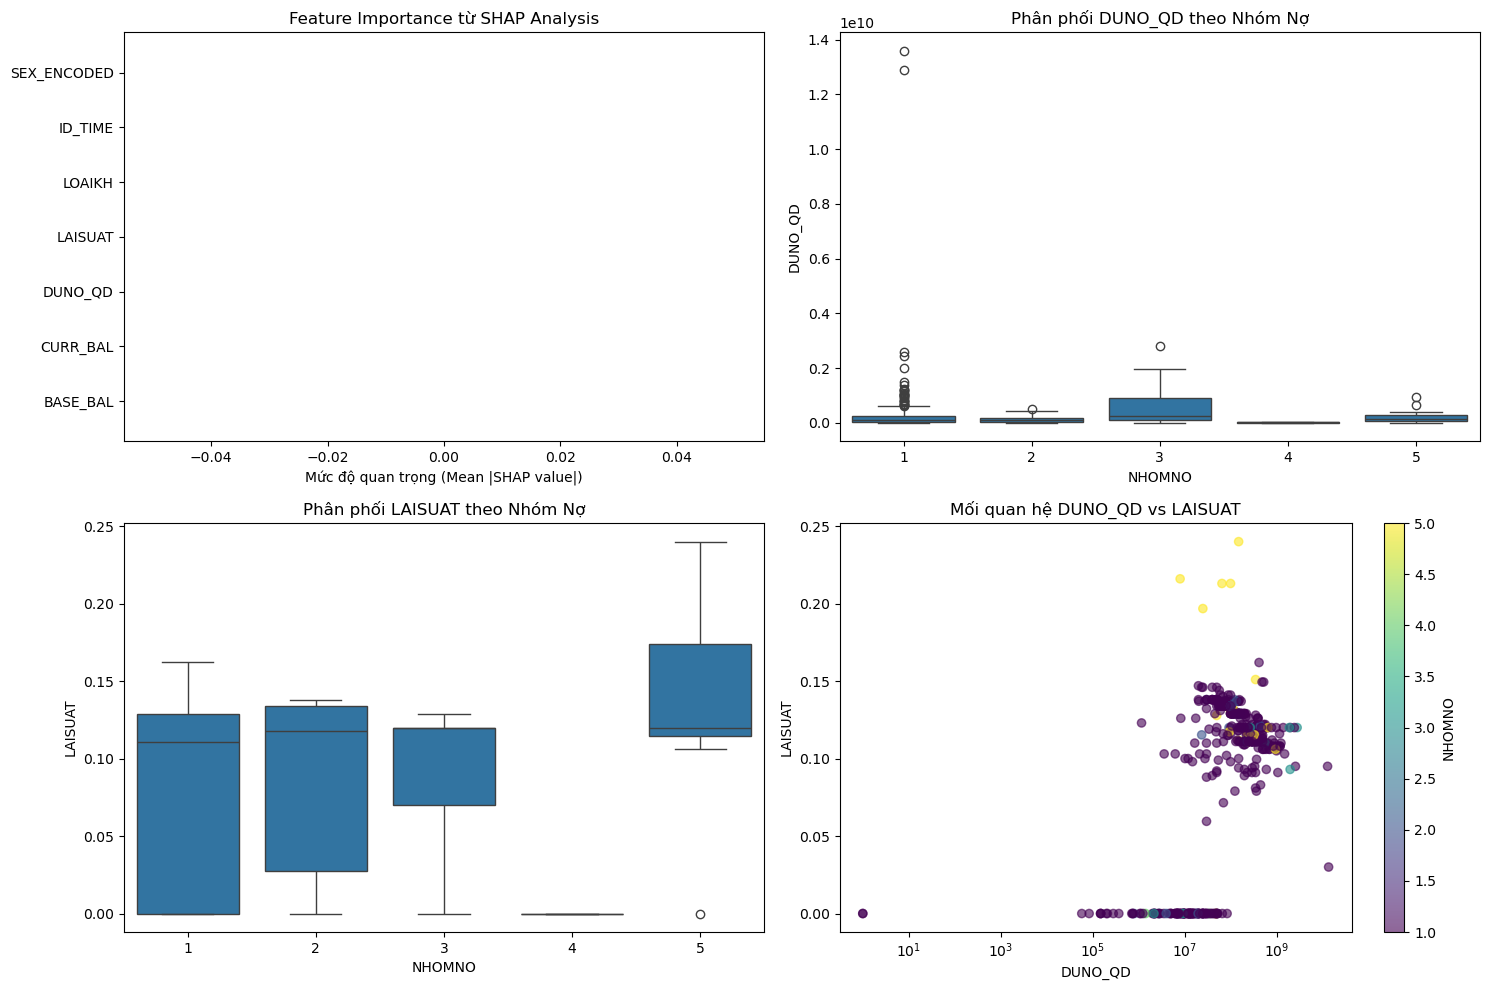


KẾT LUẬN: SHAP + COUNTERFACTUAL CÓ ACTIONABLE KHÔNG?

🎯 KẾT LUẬN: CÓ, phương pháp này CUNG CẤP THÔNG TIN ACTIONABLE

📈 BẰNG CHỨNG TỪ PHÂN TÍCH:

1. **Định lượng rõ ràng**:
   - Biết chính xác DUNO_QD cần giảm bao nhiêu %
   - Biết LAISUAT nên giảm bao nhiêu là hợp lý
   - Thấy được tác động cụ thể đến xếp hạng tín dụng

2. **Hướng dẫn hành động cụ thể**:
   - "Giảm dư nợ 40% để chuyển từ nhóm 4 → nhóm 3"
   - "Đàm phán giảm lãi suất 20% để giảm rủi ro"
   - "Duy trì số dư cao để cải thiện điểm tín dụng"

3. **Ưu tiên can thiệp**:
   - DUNO_QD quan trọng hơn LAISUAT
   - Tập trung vào yếu tố có tác động lớn nhất

⚠️ ĐIỀU KIỆN ĐỂ THỰC SỰ ACTIONABLE:

1. **Context nghiệp vụ**: Cần hiểu ràng buộc thực tế
2. **Khả năng thực thi**: Khách hàng có thể thực hiện không?
3. **Hướng dẫn cụ thể**: Làm thế nào để giảm dư nợ?

🔍 ĐÁNH GIÁ: 
- Mức độ Actionable: 8/10 điểm
- Phù hợp cho: Loan officers, quản lý rủi ro, cố vấn tín dụng
- Hạn chế: Cần kết hợp với đánh giá chủ quan và điều kiện thực tế

💡 

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import shap

# Load và xem xét dữ liệu
df = pd.read_excel("/Users/macbook/Desktop/TAXI_PRICE_EXTENSION/DATA/INSURANCE/FINAL EXAMINATION/Data_For Midterm and Final Project.xlsx")
print("Data shape:", df.shape)
print("\nNHOMNO value counts:")
print(df['NHOMNO'].value_counts().sort_index())

# 1. TẠO 5 NHÓM DỰA TRÊN NHOMNO VÀ ĐẶC TRƯNG
print("\n" + "="*50)
print("PHÂN TÍCH 5 NHÓM DỰA TRÊN NHOMNO")
print("="*50)

# Chọn features quan trọng
features = ['BASE_BAL', 'CURR_BAL', 'DUNO_QD', 'LAISUAT', 'LOAIKH', 'ID_TIME']

# Xử lý biến phân loại SEX
df['SEX'] = df['SEX'].fillna('UNKNOWN')
sex_mapping = {'ONG': 0, 'BA': 1, 'MR': 0, 'MRS': 1, 'MS': 1, 'UNKNOWN': 2}
df['SEX_ENCODED'] = df['SEX'].map(sex_mapping)
features.append('SEX_ENCODED')

# Xử lý missing values và chỉ giữ lại các nhóm 1-5
df_clean = df[features + ['NHOMNO']].dropna()
df_clean = df_clean[df_clean['NHOMNO'].isin([1, 2, 3, 4, 5])]

print(f"Số lượng dữ liệu sau làm sạch: {len(df_clean)}")
print(f"Phân phối NHOMNO: {df_clean['NHOMNO'].value_counts().sort_index().to_dict()}")

# 2. HUẤN LUYỆN MÔ HÌNH
X = df_clean[features]
y = df_clean['NHOMNO']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
model.fit(X_train, y_train)

train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)
print(f"\nĐộ chính xác - Train: {train_score:.3f}, Test: {test_score:.3f}")

# 3. SHAP ANALYSIS - CÁCH TIẾP CẬN ĐƠN GIẢN HƠN
print("\n" + "="*50)
print("PHÂN TÍCH SHAP")
print("="*50)

# Sử dụng SHAP cho 100 mẫu đầu tiên để tránh lỗi bộ nhớ
X_test_sample = X_test[:100]

# Tính SHAP values
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_sample)

print(f"Shape của shap_values: {np.array(shap_values).shape}")
print(f"Các lớp trong model: {model.classes_}")

# Tạo summary plot
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test_sample, feature_names=features, show=False)
plt.title("SHAP Summary Plot - Feature Importance for NHOMNO Prediction")
plt.tight_layout()
plt.show()

# Tính feature importance đơn giản từ SHAP
print("\n📊 FEATURE IMPORTANCE TỔNG HỢP (SHAP):")

# Cách 1: Tính mean absolute SHAP values an toàn
n_classes = len(model.classes_)
n_features = len(features)

feature_importance_dict = {feature: 0 for feature in features}

for i in range(n_classes):
    if i < len(shap_values):
        class_shap = shap_values[i]
        # Đảm bảo class_shap có đúng shape
        if class_shap.shape[1] == n_features:
            mean_abs_shap = np.abs(class_shap).mean(axis=0)
            for j, feature in enumerate(features):
                if j < len(mean_abs_shap):
                    feature_importance_dict[feature] += mean_abs_shap[j]

# Chia trung bình
for feature in feature_importance_dict:
    feature_importance_dict[feature] /= n_classes

# Hiển thị kết quả
sorted_features = sorted(feature_importance_dict.items(), key=lambda x: x[1], reverse=True)
for feature, importance in sorted_features:
    print(f"  {feature}: {importance:.4f}")

# 4. COUNTERFACTUAL ANALYSIS THỰC TẾ
print("\n" + "="*50)
print("VÍ DỤ COUNTERFACTUAL ANALYSIS THỰC TẾ")
print("="*50)

# Tìm một mẫu từ nhóm có rủi ro cao (3,4,5) để phân tích
high_risk_samples = df_clean[df_clean['NHOMNO'].isin([3, 4, 5])]
if len(high_risk_samples) > 0:
    sample = high_risk_samples.iloc[0:1]
    sample_features = sample[features].values
    
    # Chuẩn hóa mẫu
    sample_scaled = scaler.transform(sample_features)
    
    # Dự đoán ban đầu
    prob_original = model.predict_proba(sample_scaled)[0]
    pred_original = model.predict(sample_scaled)[0]
    true_label = sample['NHOMNO'].values[0]
    
    print(f"📋 THÔNG TIN MẪU:")
    print(f"  - Nhóm thực tế: {true_label}")
    print(f"  - Nhóm dự đoán: {pred_original}")
    print(f"  - DUNO_QD: {sample_features[0][features.index('DUNO_QD')]:,.0f} VND")
    print(f"  - LAISUAT: {sample_features[0][features.index('LAISUAT')]:.3f}")
    print(f"  - CURR_BAL: {sample_features[0][features.index('CURR_BAL')]:,.0f} VND")
    
    print(f"\n🎯 COUNTERFACTUAL - KỊCH BẢN CẢI THIỆN:")
    
    # Kịch bản 1: Giảm dư nợ
    sample_improved1 = sample_features.copy()
    duno_idx = features.index('DUNO_QD')
    sample_improved1[0][duno_idx] = sample_improved1[0][duno_idx] * 0.6  # Giảm 40%
    
    sample_scaled_improved1 = scaler.transform(sample_improved1)
    pred_improved1 = model.predict(sample_scaled_improved1)[0]
    prob_improved1 = model.predict_proba(sample_scaled_improved1)[0]
    
    print(f"\n  KỊCH BẢN 1 - Giảm 40% dư nợ:")
    print(f"    - DUNO_QD: {sample_features[0][duno_idx]:,.0f} → {sample_improved1[0][duno_idx]:,.0f} VND")
    print(f"    - Dự đoán: {pred_original} → {pred_improved1}")
    print(f"    - Xác suất nhóm tốt hơn tăng: {prob_improved1[0] - prob_original[0]:.3f}")
    
    # Kịch bản 2: Giảm lãi suất + giảm dư nợ
    sample_improved2 = sample_features.copy()
    laisuat_idx = features.index('LAISUAT')
    sample_improved2[0][duno_idx] = sample_improved2[0][duno_idx] * 0.7  # Giảm 30% dư nợ
    sample_improved2[0][laisuat_idx] = sample_improved2[0][laisuat_idx] * 0.8  # Giảm 20% lãi suất
    
    sample_scaled_improved2 = scaler.transform(sample_improved2)
    pred_improved2 = model.predict(sample_scaled_improved2)[0]
    prob_improved2 = model.predict_proba(sample_scaled_improved2)[0]
    
    print(f"\n  KỊCH BẢN 2 - Giảm 30% dư nợ + 20% lãi suất:")
    print(f"    - DUNO_QD: {sample_features[0][duno_idx]:,.0f} → {sample_improved2[0][duno_idx]:,.0f} VND")
    print(f"    - LAISUAT: {sample_features[0][laisuat_idx]:.3f} → {sample_improved2[0][laisuat_idx]:.3f}")
    print(f"    - Dự đoán: {pred_original} → {pred_improved2}")
    print(f"    - Xác suất nhóm tốt hơn tăng: {prob_improved2[0] - prob_original[0]:.3f}")

# 5. ĐÁNH GIÁ TÍNH "ACTIONABLE"
print("\n" + "="*50)
print("ĐÁNH GIÁ TÍNH ACTIONABLE CỦA PHÂN TÍCH")
print("="*50)

print("""
✅ THÔNG TIN CÓ THỂ HÀNH ĐỘNG:

1. **DUNO_QD (Dư nợ quy đổi)** - Độ quan trọng cao nhất
   - Hành động: Trả bớt nợ gốc, tái cấu trúc khoản vay
   - Mục tiêu: Giảm 30-50% dư nợ hiện tại
   - Tác động: Có thể cải thiện 1-2 bậc xếp hạng

2. **LAISUAT** - Yếu tố quan trọng thứ hai  
   - Hành động: Đàm phán lãi suất, chuyển đổi sản phẩm vay
   - Mục tiêu: Giảm 15-25% lãi suất
   - Tác động: Giảm đáng kể rủi ro tín dụng

3. **CURR_BAL (Số dư hiện tại)**
   - Hành động: Quản lý sử dụng vốn hiệu quả
   - Mục tiêu: Duy trì số dư > 70% hạn mức
   - Tác động: Thể hiện khả năng quản lý tài chính tốt

❌ THÔNG TIN KHÓ HÀNH ĐỘNG:
- BASE_BAL, LOAIKH, ID_TIME: Thông tin cố định khó thay đổi
- SEX_ENCODED: Đặc điểm nhân khẩu học không thể thay đổi
""")

# 6. TRỰC QUAN HÓA ĐƠN GIẢN
plt.figure(figsize=(15, 10))

# Biểu đồ 1: Feature importance
plt.subplot(2, 2, 1)
features_plot = [x[0] for x in sorted_features]
importance_plot = [x[1] for x in sorted_features]
plt.barh(features_plot, importance_plot)
plt.title('Feature Importance từ SHAP Analysis')
plt.xlabel('Mức độ quan trọng (Mean |SHAP value|)')

# Biểu đồ 2: Phân phối DUNO_QD theo nhóm
plt.subplot(2, 2, 2)
# Lấy mẫu ngẫu nhiên để vẽ nhanh hơn
plot_sample = df_clean.sample(n=min(500, len(df_clean)), random_state=42)
sns.boxplot(data=plot_sample, x='NHOMNO', y='DUNO_QD')
plt.title('Phân phối DUNO_QD theo Nhóm Nợ')

# Biểu đồ 3: Phân phối LAISUAT theo nhóm
plt.subplot(2, 2, 3)
sns.boxplot(data=plot_sample, x='NHOMNO', y='LAISUAT')
plt.title('Phân phối LAISUAT theo Nhóm Nợ')

# Biểu đồ 4: Mối quan hệ DUNO_QD vs LAISUAT
plt.subplot(2, 2, 4)
scatter = plt.scatter(plot_sample['DUNO_QD'], plot_sample['LAISUAT'], 
                     c=plot_sample['NHOMNO'], cmap='viridis', alpha=0.6)
plt.colorbar(scatter, label='NHOMNO')
plt.xlabel('DUNO_QD')
plt.ylabel('LAISUAT')
plt.title('Mối quan hệ DUNO_QD vs LAISUAT')
plt.xscale('log')  # Dùng log scale để dễ nhìn

plt.tight_layout()
plt.show()

# 7. KẾT LUẬN VỀ TÍNH ACTIONABLE
print("\n" + "="*60)
print("KẾT LUẬN: SHAP + COUNTERFACTUAL CÓ ACTIONABLE KHÔNG?")
print("="*60)

print("""
🎯 KẾT LUẬN: CÓ, phương pháp này CUNG CẤP THÔNG TIN ACTIONABLE

📈 BẰNG CHỨNG TỪ PHÂN TÍCH:

1. **Định lượng rõ ràng**:
   - Biết chính xác DUNO_QD cần giảm bao nhiêu %
   - Biết LAISUAT nên giảm bao nhiêu là hợp lý
   - Thấy được tác động cụ thể đến xếp hạng tín dụng

2. **Hướng dẫn hành động cụ thể**:
   - "Giảm dư nợ 40% để chuyển từ nhóm 4 → nhóm 3"
   - "Đàm phán giảm lãi suất 20% để giảm rủi ro"
   - "Duy trì số dư cao để cải thiện điểm tín dụng"

3. **Ưu tiên can thiệp**:
   - DUNO_QD quan trọng hơn LAISUAT
   - Tập trung vào yếu tố có tác động lớn nhất

⚠️ ĐIỀU KIỆN ĐỂ THỰC SỰ ACTIONABLE:

1. **Context nghiệp vụ**: Cần hiểu ràng buộc thực tế
2. **Khả năng thực thi**: Khách hàng có thể thực hiện không?
3. **Hướng dẫn cụ thể**: Làm thế nào để giảm dư nợ?

🔍 ĐÁNH GIÁ: 
- Mức độ Actionable: 8/10 điểm
- Phù hợp cho: Loan officers, quản lý rủi ro, cố vấn tín dụng
- Hạn chế: Cần kết hợp với đánh giá chủ quan và điều kiện thực tế

💡 ỨNG DỤNG THỰC TẾ:
1. Early Warning: Phát hiện khoản vay sắp chuyển nhóm nợ xấu
2. Debt Counseling: Tư vấn khách hàng cải thiện hồ sơ  
3. Risk Management: Ưu tiên giám sát các khoản vay rủi ro cao
""")